# CarDD YOLO11 fine-tune

YOLO11 on CarDD (6 classes: dent, scratch, crack, glass shatter, lamp broken, tire flat).
Model size set via `MODEL_VARIANT` below.

Setup: attach `CarDD_COCO` as a dataset input, GPU + Internet on, run top to bottom.


In [1]:
!pip install -q ultralytics==8.4.90

import torch, ultralytics
print("ultralytics", ultralytics.__version__)
print("torch", torch.__version__, "cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
assert torch.cuda.is_available(), "Enable GPU in Notebook Settings (Accelerator: GPU T4 x2 or P100) before continuing."


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.90
torch 2.10.0+cu128 cuda available: True
GPU: Tesla T4


## Confirm dataset mount path
Set `KAGGLE_INPUT_DIR` below to match.

In [12]:
import json
from pathlib import Path

# <-- edit this to match the folder name printed above
KAGGLE_INPUT_DIR = Path("/kaggle/input/datasets/jingshi/cardd-coco")

# Model size: yolo11n (nano) / yolo11s (small) / yolo11m / yolo11l / yolo11x
# Swap here to try a different size later - everything below reads from this one setting.
MODEL_VARIANT = "yolo11n"
RUN_NAME = f"cardd_{MODEL_VARIANT}"

COCO_ROOT = KAGGLE_INPUT_DIR / "CarDD_COCO" if (KAGGLE_INPUT_DIR / "CarDD_COCO").exists() else KAGGLE_INPUT_DIR
OUT_ROOT = Path("/kaggle/working/cardd_yolo")
SPLITS = ["train2017", "val2017", "test2017"]
EXPECTED_COUNTS = {"train2017": 2816, "val2017": 810, "test2017": 374}

assert (COCO_ROOT / "annotations" / "instances_train2017.json").exists(), (
    f"Can't find CarDD annotations under {COCO_ROOT} - check KAGGLE_INPUT_DIR matches the mount name above"
)

# Class names read from the dataset's own JSON rather than hardcoded (matches scripts/convert_coco_to_yolo.py)
with open(COCO_ROOT / "annotations" / "instances_train2017.json") as f:
    _categories = json.load(f)["categories"]
_ids = sorted(c["id"] for c in _categories)
assert _ids == list(range(1, len(_ids) + 1)), f"Expected contiguous category ids starting at 1, got {_ids}"
CLASS_NAMES = [c["name"] for c in sorted(_categories, key=lambda c: c["id"])]

print("Using COCO_ROOT =", COCO_ROOT)
print("Model variant =", MODEL_VARIANT, "-> run name:", RUN_NAME)
print("Class names:", CLASS_NAMES)


Using COCO_ROOT = /kaggle/input/datasets/jingshi/cardd-coco/CarDD_COCO
Model variant = yolo11n -> run name: cardd_yolo11n
Class names: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


## COCO -> YOLO conversion
`cls91to80=False` — CarDD's category ids are custom, not COCO's.

In [13]:
import shutil
from ultralytics.data.converter import convert_coco

if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)  # convert_coco increments the dir name instead of overwriting

convert_coco(
    labels_dir=str(COCO_ROOT / "annotations"),
    save_dir=str(OUT_ROOT),
    use_segments=False,
    use_keypoints=False,
    cls91to80=False,
)

for split in SPLITS:
    src_dir = COCO_ROOT / split
    dst_dir = OUT_ROOT / "images" / split
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img_path in src_dir.glob("*.jpg"):
        dst = dst_dir / img_path.name
        if not dst.exists():
            shutil.copy2(img_path, dst)

print(f"{'split':12s}{'images':>10s}{'label_files':>14s}")
for split in SPLITS:
    n_images = len(list((OUT_ROOT / "images" / split).glob("*.jpg")))
    n_labels = len(list((OUT_ROOT / "labels" / split).glob("*.txt")))
    print(f"{split:12s}{n_images:10d}{n_labels:14d}")
    if n_images != EXPECTED_COUNTS[split]:
        print(f"  WARNING: expected {EXPECTED_COUNTS[split]} images for split '{split}', found "
              f"{n_images} - check the upload/attachment completed correctly.")


Annotations /kaggle/input/datasets/jingshi/cardd-coco/CarDD_COCO/annotations/instances_test2017.json: 100% ━━━━━━━━━━━━ 374/374 7.7Kit/s 0.0s
Annotations /kaggle/input/datasets/jingshi/cardd-coco/CarDD_COCO/annotations/instances_train2017.json: 100% ━━━━━━━━━━━━ 2816/2816 7.8Kit/s 0.4s0.1s
Annotations /kaggle/input/datasets/jingshi/cardd-coco/CarDD_COCO/annotations/instances_val2017.json: 100% ━━━━━━━━━━━━ 810/810 8.2Kit/s 0.1s
COCO data converted successfully.
Results saved to /kaggle/working/cardd_yolo
split           images   label_files
train2017         2816          2816
val2017            810           810
test2017           374           374


In [14]:
import yaml

data_yaml = {
    "path": str(OUT_ROOT.resolve()),
    "train": "images/train2017",
    "val": "images/val2017",
    "test": "images/test2017",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
data_yaml_path = Path("/kaggle/working/cardd_yolo.yaml")
with open(data_yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)
print(data_yaml_path.read_text())


path: /kaggle/working/cardd_yolo
train: images/train2017
val: images/val2017
test: images/test2017
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



## Sanity check
Redraw decoded YOLO boxes to confirm the conversion before training.

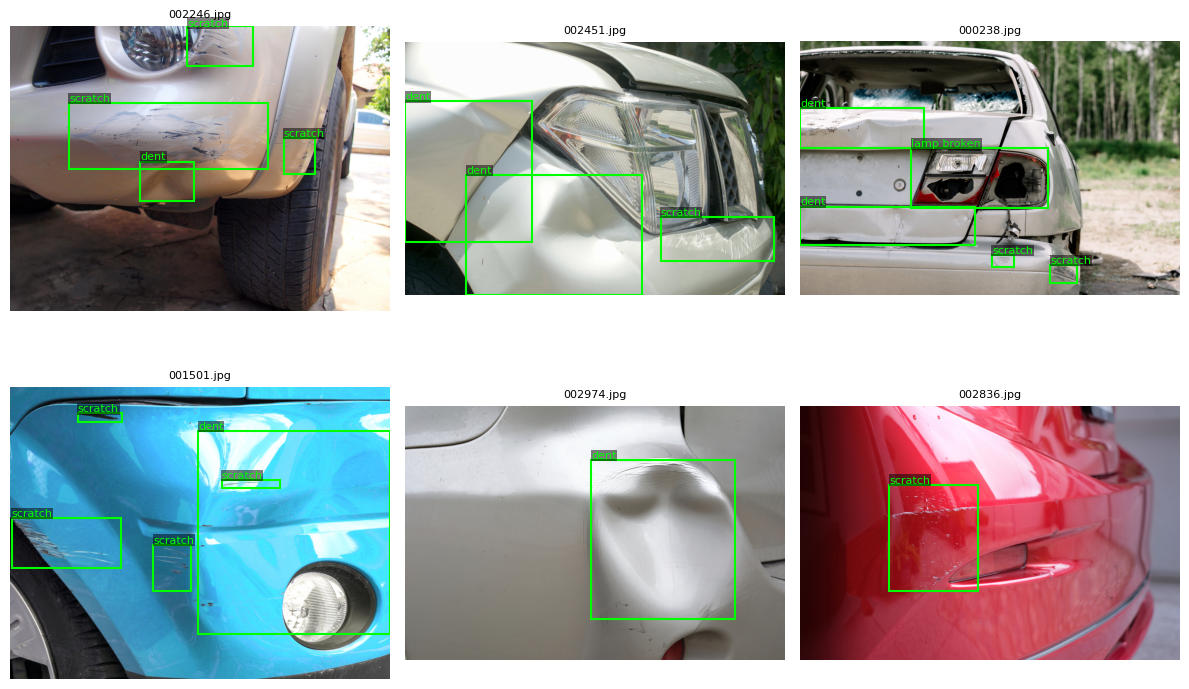

In [15]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

random.seed(0)
img_dir = OUT_ROOT / "images/train2017"
lbl_dir = OUT_ROOT / "labels/train2017"
sample = random.sample(sorted(img_dir.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, img_path in zip(axes.flatten(), sample):
    im = plt.imread(img_path)
    h, w = im.shape[:2]
    ax.imshow(im)
    lbl_path = lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            cls, cx, cy, bw, bh = line.split()[:5]
            cls = int(cls)
            cx, cy, bw, bh = float(cx) * w, float(cy) * h, float(bw) * w, float(bh) * h
            x0, y0 = cx - bw / 2, cy - bh / 2
            ax.add_patch(patches.Rectangle((x0, y0), bw, bh, linewidth=1.5, edgecolor="lime", facecolor="none"))
            ax.text(x0, max(y0 - 4, 0), CLASS_NAMES[cls], color="lime", fontsize=8,
                     bbox=dict(facecolor="black", alpha=0.5, pad=0.5, edgecolor="none"))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
fig.tight_layout()
plt.savefig("/kaggle/working/sanity_check.png", dpi=150)
plt.show()


## Train
Fixed seed, early stopping via `patience`, RAM caching (dataset is small).

In [16]:
from ultralytics import YOLO

model = YOLO(f"{MODEL_VARIANT}.pt")
train_results = model.train(
    data=str(data_yaml_path),
    epochs=100,
    imgsz=640,
    batch=16,
    seed=0,
    deterministic=True,
    patience=20,
    device=0,
    cache="ram",
    project="/kaggle/working/runs",
    name=RUN_NAME,
    exist_ok=True,
)


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cardd_yolo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cardd_yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

## Test set evaluation
Separate from training-time val — this is the headline number.

In [17]:
best_weights = f"/kaggle/working/runs/{RUN_NAME}/weights/best.pt"
test_model = YOLO(best_weights)
test_metrics = test_model.val(
    data=str(data_yaml_path),
    split="test",
    project="/kaggle/working/runs",
    name=f"{RUN_NAME}_test",
)

print("Test mAP50:", test_metrics.box.map50)
print("Test mAP50-95:", test_metrics.box.map)
print("Test mean precision:", test_metrics.box.mp)
print("Test mean recall:", test_metrics.box.mr)

print(f"\n{'class':15s}{'precision':>10s}{'recall':>10s}{'F1':>10s}{'AP50':>10s}{'AP50-95':>10s}")
for i, cls_idx in enumerate(test_metrics.box.ap_class_index):
    name = CLASS_NAMES[int(cls_idx)]
    p, r, ap50, ap = test_metrics.box.class_result(i)
    f1 = test_metrics.box.f1[i]
    print(f"{name:15s}{p:10.4f}{r:10.4f}{f1:10.4f}{ap50:10.4f}{ap:10.4f}")


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3107.1±891.0 MB/s, size: 755.6 KB)
val: Scanning /kaggle/working/cardd_yolo/labels/test2017... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 1.1Kit/s 0.4s<0.1s
val: New cache created: /kaggle/working/cardd_yolo/labels/test2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 5.3it/s 4.5s0.1s
                   all        374        785      0.783      0.685      0.728      0.568
                  dent        157        236      0.705      0.542      0.623      0.346
               scratch        183        307      0.648      0.558      0.584      0.304
                 crack         48         70      0.558        0.4      0.394       0.21
         glass shatter         71         71  

## Qualitative examples
Sample predictions for the README.

In [18]:
import random
random.seed(1)
test_images = sorted((OUT_ROOT / "images/test2017").glob("*.jpg"))
sample_imgs = random.sample(test_images, 8)
test_model.predict(
    source=[str(p) for p in sample_imgs],
    save=True,
    conf=0.25,
    project="/kaggle/working/runs",
    name=f"{RUN_NAME}_qualitative",
)



0: 640x640 1 scratch, 1 tire flat, 7.2ms
1: 640x640 1 glass shatter, 7.2ms
2: 640x640 3 dents, 2 scratchs, 1 crack, 7.2ms
3: 640x640 1 scratch, 1 crack, 1 lamp broken, 7.2ms
4: 640x640 1 tire flat, 7.2ms
5: 640x640 1 dent, 2 scratchs, 7.2ms
6: 640x640 1 scratch, 7.2ms
7: 640x640 3 dents, 1 scratch, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/cardd_yolo11n_qualitative


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
 obb: None
 orig_img: array([[[241, 248, 251],
         [242, 248, 253],
         [241, 247, 254],
         ...,
         [112,  98, 169],
         [118, 104, 175],
         [126, 112, 183]],
 
        [[249, 254, 255],
         [243, 249, 254],
         [243, 250, 253],
         ...,
         [121, 109, 181],
         [129, 116, 190],
         [133, 121, 197]],
 
        [[250, 250, 255],
         [248, 252, 253],
         [249, 253, 254],
         ...,
         [135, 122, 196],
         [135, 123, 199],
         [133, 123, 199]],
 
        ...,
 
        [[ 41,  40,  42],
         [ 36,  34,  40],
         [ 33,  35,  36],
         ...,
         [176, 158, 147],
         [167, 149, 142],
         [159, 140, 132]],
 
        [[ 44,  45,  49],
      

## Package outputs
Download the zip + this notebook into the local repo.

In [19]:
import shutil

zip_path = f"/kaggle/working/{RUN_NAME}_results"
shutil.make_archive(zip_path, "zip", "/kaggle/working/runs")
print(f"Zipped run artifacts to {zip_path}.zip\n")
print("Key files inside runs/:")
print(f"  weights:               {RUN_NAME}/weights/best.pt")
print(f"  train metrics/plots:   {RUN_NAME}/results.csv, results.png, confusion_matrix.png, PR_curve.png")
print(f"  held-out test metrics: {RUN_NAME}_test/")
print(f"  qualitative preds:     {RUN_NAME}_qualitative/")


Zipped run artifacts to /kaggle/working/cardd_yolo11n_results.zip

Key files inside runs/:
  weights:               cardd_yolo11n/weights/best.pt
  train metrics/plots:   cardd_yolo11n/results.csv, results.png, confusion_matrix.png, PR_curve.png
  held-out test metrics: cardd_yolo11n_test/
  qualitative preds:     cardd_yolo11n_qualitative/
